In [ ]:
#OVERFITTING DEMONSTRATION AND EARLY STOPPING


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [ ]:
x_train_small=x_train[:2000]
y_train_small=y_train[:2000]
def build_mlp():
  model=models.Sequential([layers.Input(shape=(784,)),layers.Dense(512,activation='relu'),layers.Dense(256,activation='relu'),layers.Dense(10,activation='softmax')])
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model

In [ ]:
print("\nTraining without earlystopping")
model_no_es=build_mlp()
history_no_es=model_no_es.fit(x_train_small,y_train_small,epochs=50,validation_split=0.2,batch_size=64,verbose=1)


Training without earlystopping
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5795 - loss: 1.5030 - val_accuracy: 0.8875 - val_loss: 0.4008
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8846 - loss: 0.3901 - val_accuracy: 0.9175 - val_loss: 0.2850
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9192 - loss: 0.2524 - val_accuracy: 0.9125 - val_loss: 0.2730
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9549 - loss: 0.1604 - val_accuracy: 0.9325 - val_loss: 0.2223
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9815 - loss: 0.0871 - val_accuracy: 0.9275 - val_loss: 0.2132
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9948 - loss: 0.0508 - val_accuracy: 0.9425 - val_loss: 0.2030
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9963 - loss: 0.0344 - val_accuracy: 0.9375 - val_loss: 0.2096
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9996 - loss: 0

In [ ]:
print("\nTraining with earlystopping")
model_es=build_mlp()
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
history_es=model_es.fit(x_train_small,y_train_small,epochs=50,validation_split=0.2,batch_size=64,callbacks=[early_stop],verbose=1)


Training with earlystopping
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5482 - loss: 1.5222 - val_accuracy: 0.8950 - val_loss: 0.3718
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8871 - loss: 0.3921 - val_accuracy: 0.9125 - val_loss: 0.3270
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9269 - loss: 0.2286 - val_accuracy: 0.9325 - val_loss: 0.2461
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9587 - loss: 0.1624 - val_accuracy: 0.9300 - val_loss: 0.2217
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9792 - loss: 0.1059 - val_accuracy: 0.9300 - val_loss: 0.2352
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9843 - loss: 0.0765 - val_accuracy: 0.9475 - val_loss: 0.2052
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9971 - loss: 0.0369 - val_accuracy: 0.9425 - val_loss: 0.2058
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.01

In [ ]:
loss_no_es,acc_no_es=model_no_es.evaluate(x_test,y_test,verbose=1)
loss_es,acc_es=model_es.evaluate(x_test,y_test,verbose=1)
print(f"\nTest Accuracy without early stopping:{acc_no_es:.4f}")
print(f"\nTest Accuracy with early stopping:{acc_es:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9043 - loss: 0.4569
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9007 - loss: 0.3634

Test Accuracy without early stopping:0.9186

Test Accuracy with early stopping:0.9132


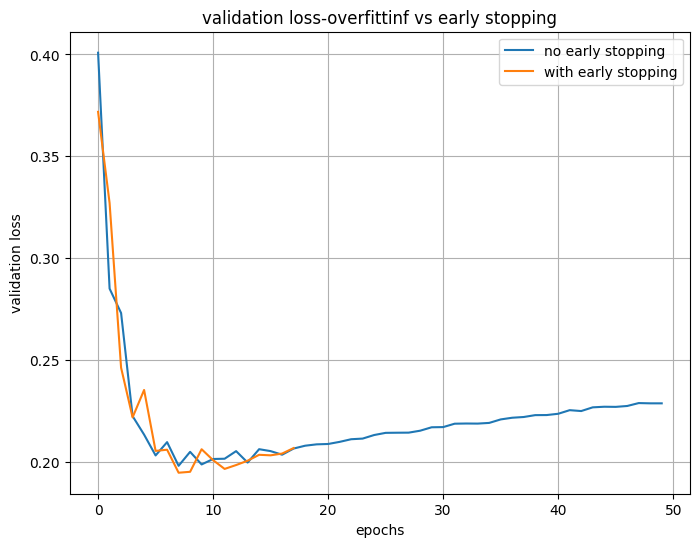

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history_no_es.history['val_loss'],label='no early stopping')
plt.plot(history_es.history['val_loss'],label='with early stopping')
plt.title("validation loss-overfittinf vs early stopping")
plt.xlabel("epochs")
plt.ylabel("validation loss")
plt.legend()
plt.grid(True)
plt.show()
